In [1]:
# Dirichlet‑Process clustering of NDVI time series
# Piece‑wise (Loredo‑style) temporal model
# PyMC implementation with truncated DP and sequential updating

import numpy as np
import pymc as pm
import pytensor.tensor as pt
from matplotlib import pyplot as plt

import scipy.stats as stats

In [2]:
N_SEGMENTS = 23

In [3]:
# ============================================================
# UTILITIES
# ============================================================

def doy_to_bin(doy, n_segments=N_SEGMENTS):
    """Map day-of-year to piecewise bin"""
    return np.floor((doy % 365) / 365 * n_segments).astype(int)

### levanto series NDVI

In [4]:
import pandas as pd

In [5]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [6]:
nSeries = 100

In [7]:
ndviDataStart = 7
testPixel = np.random.choice(df.shape[0], size=nSeries, replace=False)

### reconstruyo vector fechas

In [8]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])

### Incluyo fecha deforestacion

In [9]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [10]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [12]:
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,0.327133,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,0.333600,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,0.336400,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,0.351067,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,0.351200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,0.291600,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,0.303000,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [13]:
ndviDataStart+=1

In [14]:
fechas.shape

(430,)

In [15]:
ndviDataStart

8

/tmp/ipykernel_59509/4001357351.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


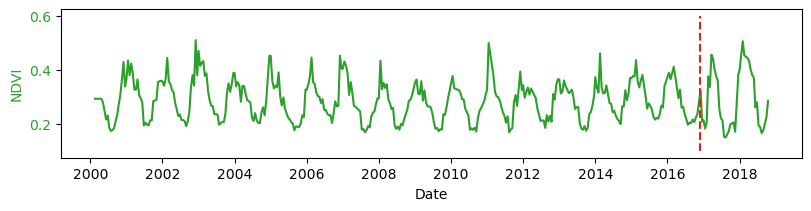

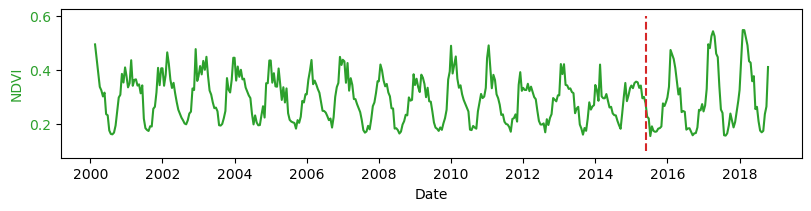

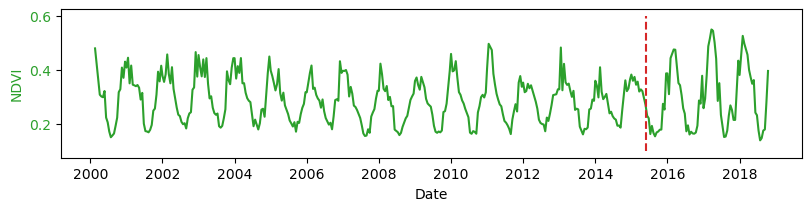

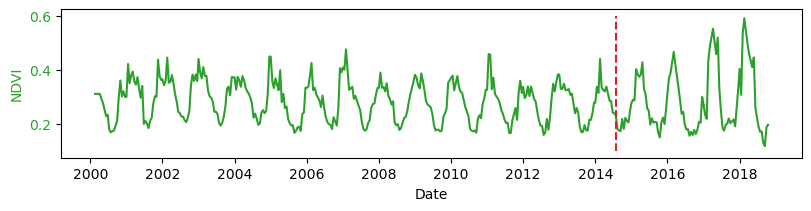

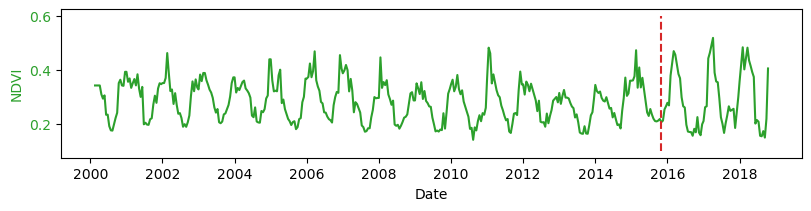

In [16]:
for pixel in testPixel[:5]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart-1:].values

    # plt.plot(fechas, ndvi)
    # plt.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
    # plt.show()

    fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    color1 = 'tab:green'
    color2 = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('NDVI', color=color1)
    ax1.plot(fechas, ndvi, color=color1)
    ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
    ax1.tick_params(axis='y', labelcolor=color1)

    fig.show()

### Separo bosque no bosque temporal!

In [17]:
pixel = testPixel[0]
deforestationDate = df['fechaDef'].iloc[pixel]
ndvi = df.iloc[pixel, ndviDataStart-1:].values

In [18]:
deforestationDate.to_julian_date()

2457723.5

In [19]:
fechas.to_julian_date()

Index([2451592.5, 2451608.5, 2451624.5, 2451640.5, 2451656.5, 2451672.5,
       2451688.5, 2451704.5, 2451720.5, 2451736.5,
       ...
       2458263.5, 2458279.5, 2458295.5, 2458311.5, 2458327.5, 2458343.5,
       2458359.5, 2458375.5, 2458391.5, 2458407.5],
      dtype='float64', length=430)

In [20]:
nSeriesToTrain = 30

In [21]:
series = []

ANIOS_ENTRENAMIENTO = 3

for pixel in testPixel[:nSeriesToTrain]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    # defIndex = np.argmax(fechas == deforestationDate)
    defIndex = np.argmin(np.abs(fechas.to_julian_date() - deforestationDate.to_julian_date()))
    
    firstJanIndex = np.argmax(fechas[defIndex:].month == 1) + defIndex #indice del primer enero después de la deforestación
    lastJanIndex = defIndex - np.argmax(np.flip(fechas[:defIndex].month == 1)) -1 #indice del ultimo enero antes de la deforestación

    # bosque = df.iloc[pixel, ndviDataStart-1:defIndex].values # todo el bosque
    bosque = df.iloc[pixel, lastJanIndex-(N_SEGMENTS*ANIOS_ENTRENAMIENTO):lastJanIndex].values # solo los tres años antes de la deforestación
    noBosque = df.iloc[pixel, firstJanIndex:firstJanIndex+(N_SEGMENTS*ANIOS_ENTRENAMIENTO)].values #segmento de tres años primer enero después de la deforestación

    if len(noBosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos después de la deforestación para el pixel {pixel}.")
        continue

    if len(bosque) < N_SEGMENTS*ANIOS_ENTRENAMIENTO:
        print(f"Advertencia: no hay suficientes datos antes de la deforestación para el pixel {pixel}.")
        continue
    
    if False:
        fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    series.append(bosque)
    series.append(noBosque)

    if False:
        color1 = 'tab:green'
        color2 = 'tab:red'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('NDVI', color=color1)
        ax1.plot(bosque, color=color1)
        ax1.plot(noBosque, color=color2)
        # ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
        ax1.tick_params(axis='y', labelcolor=color1)

        fig.show()

Advertencia: no hay suficientes datos después de la deforestación para el pixel 487.
Advertencia: no hay suficientes datos después de la deforestación para el pixel 507.


In [22]:
quincenas = np.arange(0, 23*3)

In [23]:
quincenas.shape

(69,)

In [24]:
series = np.array(series)

In [25]:
series.shape

(56, 69)

In [26]:
#quincenas, series, true_clusters = synthetic_series(n_series=30, anios=3, sigma=SIGMA_MODIS)

In [27]:
# true_clusters 
true_clusters = [x%2 for x in range(series.shape[0])]

Text(0.5, 1.0, 'Series reales con clusters conocidos')

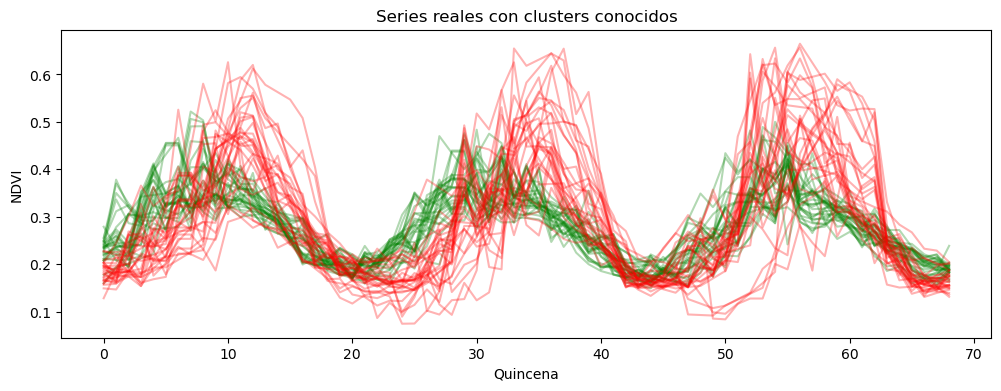

In [28]:
fig = plt.figure(figsize=(12,4))

plt.plot(quincenas, series[0::2, :].T, color='green', alpha=0.3)
plt.plot(quincenas, series[1::2, :].T, color='red', alpha=0.3)
plt.xlabel("Quincena")
plt.ylabel("NDVI")
plt.title("Series reales con clusters conocidos")

In [29]:
series = np.asarray(series, dtype=np.float32)

In [30]:
np.isnan(series).sum()

0

In [31]:
NSeries, T = series.shape

### Inferencia

In [32]:
from scipy.interpolate import BSpline

In [33]:
def bspline_basis(t, knots, degree=3):

    n_basis = len(knots) - degree - 1
    basis = np.zeros((len(t), n_basis))

    for i in range(n_basis):

        coeff = np.zeros(n_basis)
        coeff[i] = 1

        spline = BSpline(knots, coeff, degree)

        basis[:, i] = spline(t)

    return basis

In [34]:
T

69

In [57]:
# T = len(t)
# knots = np.linspace(0, T, 12)   # controla complejidad

degree = 3
K = 10
T = 69

t = np.arange(T)

# knots internos
internal_knots = np.linspace(0, T, K - degree + 1)

knots = np.concatenate([
    np.repeat(internal_knots[0], degree+1),
    internal_knots[1:-1],
    np.repeat(internal_knots[-1], degree+1)
])

In [58]:
# B = bspline_basis(np.arange(T), knots, degree=3)
B = bspline_basis(t, knots, degree=3)

print(B.shape)   # (69,8)

(69, 10)


Como son las splines?

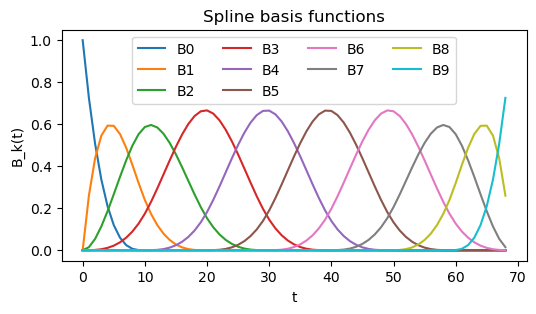

In [59]:
plt.figure(figsize=(6,3))

for k in range(B.shape[1]):
    plt.plot(np.arange(T), B[:,k], label=f"B{k}")

plt.title("Spline basis functions")
plt.xlabel("t")
plt.ylabel("B_k(t)")
plt.legend(ncol=4)
plt.show()

In [60]:
B.sum(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])

que soporte expanden?

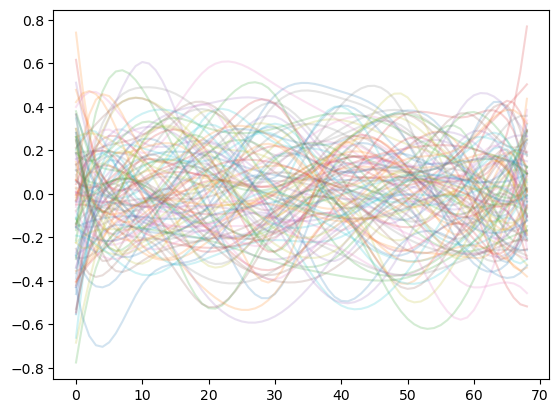

In [62]:
for _ in range(100):
    theta = np.random.normal(0,0.3,10)
    plt.plot(np.arange(T), B @ theta, alpha=0.2)
plt.show()

In [63]:
# def build_model_B(B_, Y):

#     Y = np.asarray(Y)

#     if Y.ndim == 1:
#         Y = Y[None, :]

#     K = B_.shape[1]
#     NSeries, lengthSeries = Y.shape

#     print(B_.shape, Y.shape)

#     with pm.Model() as model:

#         theta = pm.Normal("theta", 0, 1, shape=(K, NSeries)) 
#         mu = pm.math.dot(B_, theta)
#         sigma = pm.HalfNormal("sigma", 0.05)
#         ndvi = pm.Normal("ndvi", mu=mu, sigma=sigma, observed=Y, shape=(lengthSeries, NSeries))

#     return model

def build_model_B(B_, Y):

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[:, None]

    print("B:", B_.shape, "Y:", Y.shape)

    # asegurar (T,N)
    if Y.shape[0] != B_.shape[0]:
        Y = Y.T

    T, N = Y.shape
    K = B_.shape[1]

    with pm.Model() as model:

        theta = pm.Normal("theta", 0, 0.3, shape=(K, N))
        # mu = pm.math.dot(B_, theta)
        mu = pm.Deterministic("mu", pm.math.dot(B_, theta))
        sigma = pm.HalfNormal("sigma", 0.01)

        pm.Normal(
            "ndvi",
            mu=mu,
            sigma=sigma,
            observed=Y
        )

    return model

In [64]:
model = build_model_B(B, series.T)

B: (69, 10) Y: (69, 56)


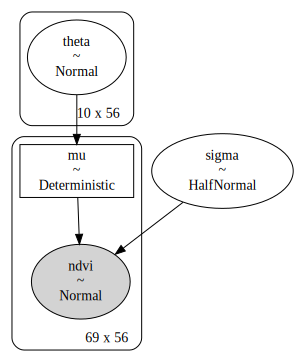

In [65]:
pm.model_to_graphviz(model)

In [66]:
for rv in model.free_RVs:
    print(rv.name, rv.eval().shape)

theta (10, 56)
sigma ()


### pruebo con series conocidas

bosque

In [67]:
bosques = series[0::2, :]
# bosque_model = build_model_rw2(bosques)
bosque_model = build_model_B(B, bosques)

with bosque_model:
        idata = pm.sample_prior_predictive()

Sampling: [ndvi, sigma, theta]


B: (69, 10) Y: (28, 69)


In [68]:
import jax, numpyro, pymc
print(jax.__version__)
print(numpyro.__version__)
print(pymc.__version__)

0.7.0
0.20.0
5.12.0


In [69]:
with bosque_model:
        idata = pm.sample(
            2000,
            tune=500,
            target_accept=0.9) #, nuts_sampler="numpyro"
        # idata = pm.sample_numpyro_nuts(
        #     2000,
        #     tune=500,
        #     target_accept=0.9
        # )


# for bosque_ in bosques[:3, :]:
#     # plt.figure(figsize=(4,1))
#     # plt.plot(bosque_)
#     serie_prueba = bosque_
#     model = build_model_rw2(serie_prueba)
#     with model:
#         idata = pm.sample(
#             1000,
#             tune=500,
#             target_accept=0.9
#         )
#     est_series = idata.posterior["ndvi"].mean(dim=["chain", "draw"])
#     plt.figure(figsize=(4,1))
#     plt.plot(bosque_,'g')
#     plt.plot(est_series.values[0],'r')    


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, sigma]
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 20 seconds.


In [70]:
import arviz as az
# az.plot_trace(idata, var_names=["sigma_obs", "sigma_rw", "mu"])
# az.plot_trace(idata)

In [71]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"theta[0, 0]",0.211,0.028,0.161,0.266,0.0,0.0,14358.0,6536.0,1.0
"theta[0, 1]",0.247,0.028,0.194,0.299,0.0,0.0,14806.0,6085.0,1.0
"theta[0, 2]",0.194,0.027,0.142,0.245,0.0,0.0,13121.0,6769.0,1.0
"theta[0, 3]",0.220,0.028,0.169,0.273,0.0,0.0,15558.0,6577.0,1.0
"theta[0, 4]",0.199,0.027,0.148,0.249,0.0,0.0,14593.0,6876.0,1.0
...,...,...,...,...,...,...,...,...,...
"mu[68, 23]",0.200,0.028,0.149,0.254,0.0,0.0,10628.0,7040.0,1.0
"mu[68, 24]",0.184,0.028,0.131,0.235,0.0,0.0,10949.0,6546.0,1.0
"mu[68, 25]",0.208,0.028,0.156,0.260,0.0,0.0,11064.0,6831.0,1.0
"mu[68, 26]",0.185,0.028,0.130,0.235,0.0,0.0,11602.0,6998.0,1.0


reconstruyo la serie

In [72]:
idata.posterior["mu"].mean(dim=["chain", "draw"])

<xarray.DataArray 'mu' (mu_dim_0: 69, mu_dim_1: 28)> Size: 15kB
array([[0.21128951, 0.24716387, 0.19373978, ..., 0.2712898 , 0.15133146,
        0.22765994],
       [0.24287169, 0.27035043, 0.22726527, ..., 0.25592004, 0.17694005,
        0.26555017],
       [0.27119217, 0.29172612, 0.25883518, ..., 0.25271459, 0.20658588,
        0.29638863],
       ...,
       [0.19516584, 0.1814169 , 0.18770736, ..., 0.1914797 , 0.15933079,
        0.19156803],
       [0.19150203, 0.18561582, 0.18053482, ..., 0.19147528, 0.16313645,
        0.19855422],
       [0.19739695, 0.20386715, 0.1799715 , ..., 0.20843055, 0.18514477,
        0.22150326]])
Coordinates:
  * mu_dim_0  (mu_dim_0) int64 552B 0 1 2 3 4 5 6 7 ... 61 62 63 64 65 66 67 68
  * mu_dim_1  (mu_dim_1) int64 224B 0 1 2 3 4 5 6 7 ... 20 21 22 23 24 25 26 27

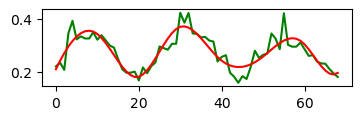

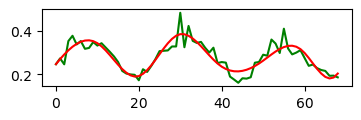

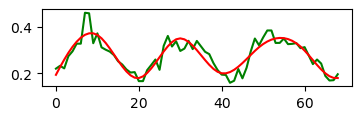

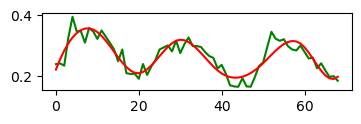

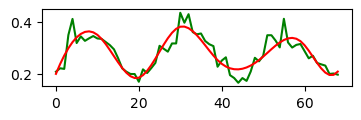

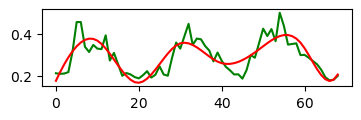

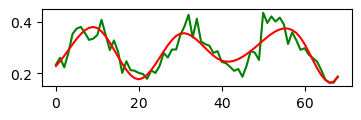

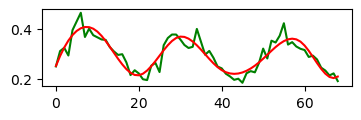

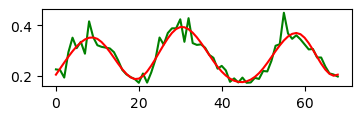

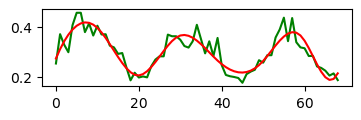

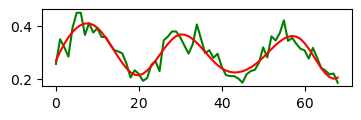

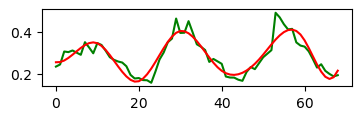

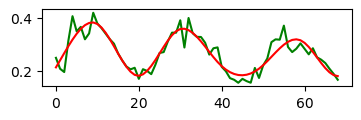

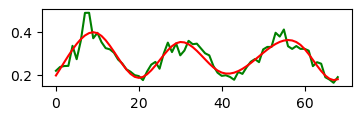

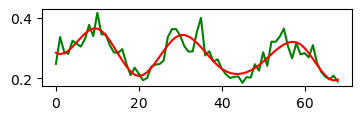

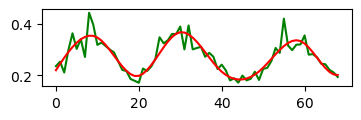

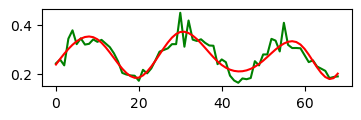

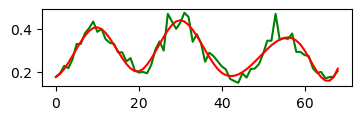

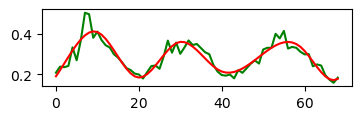

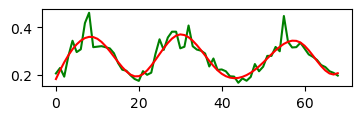

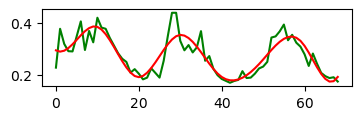

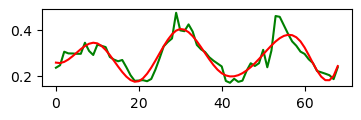

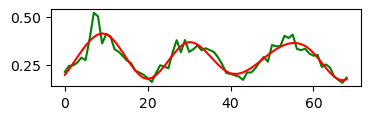

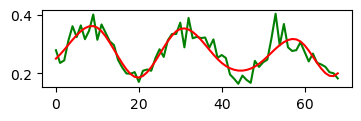

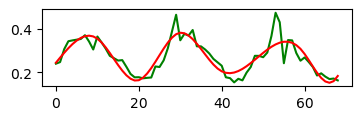

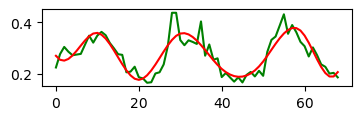

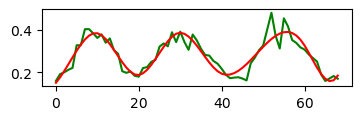

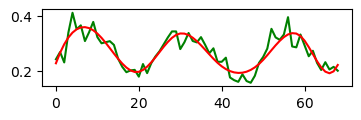

In [73]:
est_series = idata.posterior["mu"].mean(dim=["chain", "draw"])
if True:   
    for b_ in range(bosques.shape[0]):
        plt.figure(figsize=(4,1))
        plt.plot(bosques[b_,:],'g')
        plt.plot(est_series.values[:,b_],'r')
        plt.show()

Me fijo el valor del parametro theta inferido para cada serie

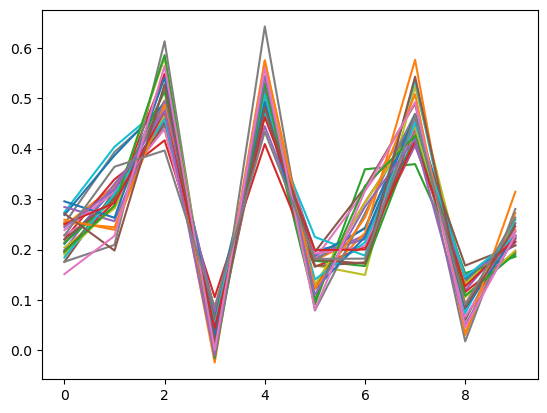

In [74]:
for i in range(bosques.shape[0]):
    plt.plot(idata.posterior["theta"].mean(dim=["chain", "draw"]).values[:,i])

No bosque

In [75]:
no_bosques = series[1::2, :]
# bosque_model = build_model_rw2(bosques)
no_bosque_model = build_model_B(B, no_bosques)

with no_bosque_model:
        idata_noBosque = pm.sample_prior_predictive()

Sampling: [ndvi, sigma, theta]


B: (69, 10) Y: (28, 69)


In [76]:
with no_bosque_model:
        idata_noBosque = pm.sample(
            2000,
            tune=500,
            target_accept=0.9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, sigma]
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 18 seconds.


In [77]:
az.summary(idata_noBosque)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"theta[0, 0]",0.178,0.052,0.083,0.275,0.0,0.001,12843.0,6871.0,1.0
"theta[0, 1]",0.171,0.051,0.077,0.269,0.0,0.001,16558.0,6886.0,1.0
"theta[0, 2]",0.215,0.052,0.115,0.309,0.0,0.001,14945.0,6729.0,1.0
"theta[0, 3]",0.242,0.052,0.140,0.336,0.0,0.001,14329.0,6054.0,1.0
"theta[0, 4]",0.174,0.052,0.073,0.267,0.0,0.001,14190.0,6009.0,1.0
...,...,...,...,...,...,...,...,...,...
"mu[68, 23]",0.145,0.051,0.044,0.238,0.0,0.001,12277.0,6681.0,1.0
"mu[68, 24]",0.214,0.051,0.119,0.310,0.0,0.000,11065.0,6710.0,1.0
"mu[68, 25]",0.217,0.052,0.124,0.317,0.0,0.001,11222.0,6845.0,1.0
"mu[68, 26]",0.213,0.051,0.119,0.311,0.0,0.000,11719.0,7233.0,1.0


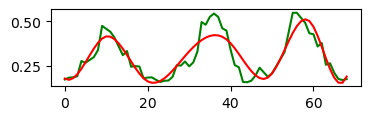

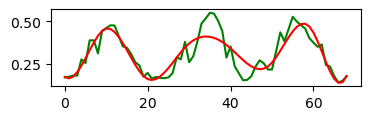

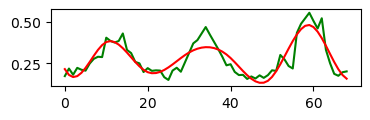

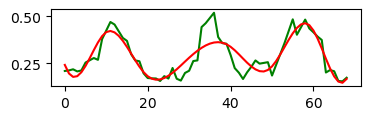

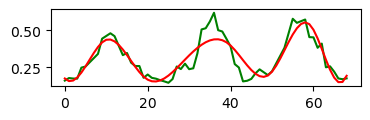

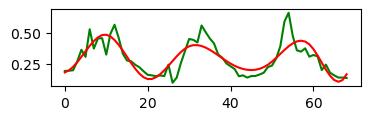

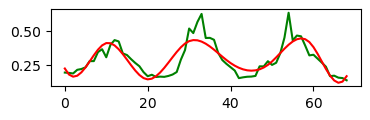

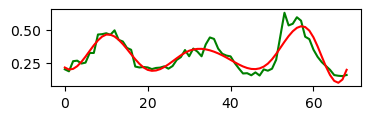

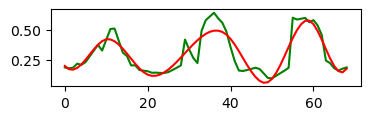

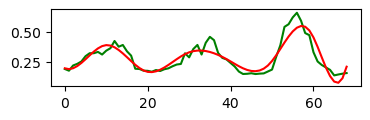

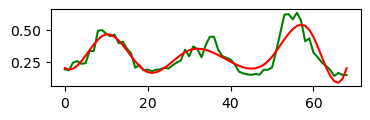

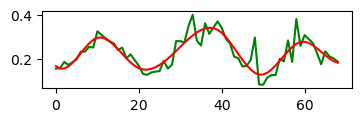

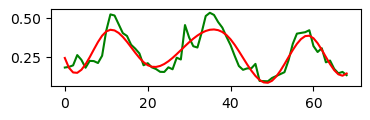

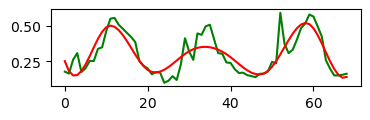

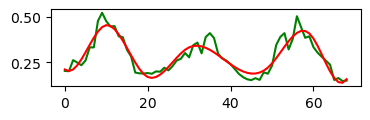

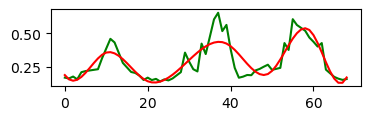

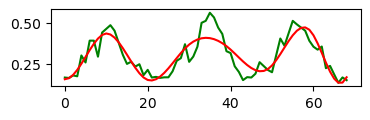

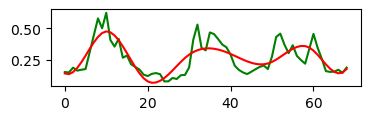

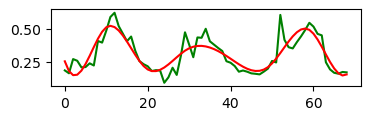

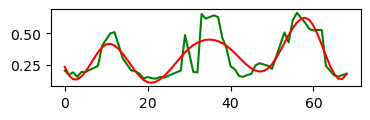

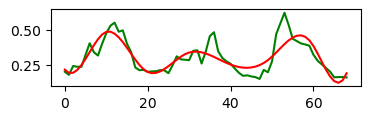

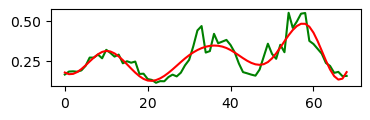

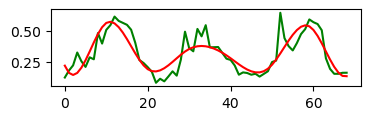

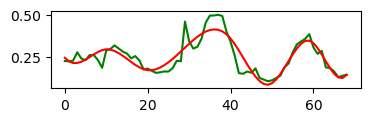

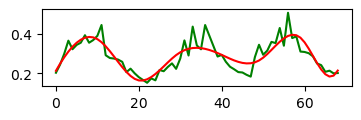

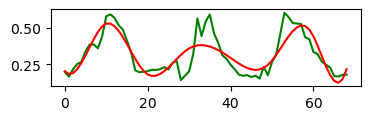

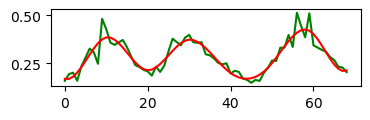

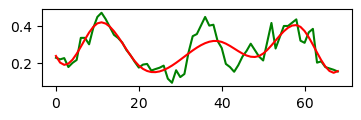

In [78]:
est_series_noBosque = idata_noBosque.posterior["mu"].mean(dim=["chain", "draw"])
if True:   
    for b_ in range(no_bosques.shape[0]):
        plt.figure(figsize=(4,1))
        plt.plot(no_bosques[b_,:],'g')
        plt.plot(est_series_noBosque.values[:,b_],'r')
        plt.show()

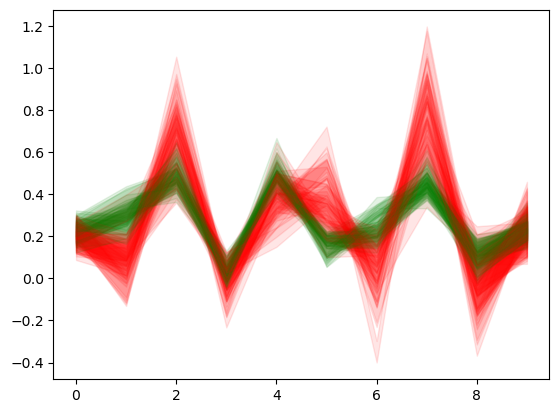

In [80]:
for i in range(no_bosques.shape[0]):
    meanNoBosque = idata_noBosque.posterior["theta"].mean(dim=["chain", "draw"]).values[:,i]
    meanBosque = idata.posterior["theta"].mean(dim=["chain", "draw"]).values[:,i]

    stdNoBosque = idata_noBosque.posterior["theta"].std(dim=["chain", "draw"]).values[:,i]
    stdBosque = idata.posterior["theta"].std(dim=["chain", "draw"]).values[:,i]

            # plt.plot(meanNoBosque,'r', alpha = 0.3)
            # plt.plot(meanBosque,'g', alpha = 0.3)
    plt.fill_between(np.arange(meanNoBosque.shape[0]), meanNoBosque-stdNoBosque, meanNoBosque+stdNoBosque, color='red', alpha=0.1)
    plt.fill_between(np.arange(meanBosque.shape[0]), meanBosque-stdBosque, meanBosque+stdBosque, color='green', alpha=0.1)
            # plt.show()

In [ ]:
import plotly.graph_objects as go

# categories = ['processing cost','mechanical properties','chemical stability',
#               'thermal stability', 'device integration']

categories = np.linspace(0, 360, 8)

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=meanBosque,
      theta=categories,
      fill='toself',
      name='Bosque', 
      # fillcolor = 'green'
))
fig.add_trace(go.Scatterpolar(
      r=meanNoBosque,
      theta=categories,
      fill='toself',
      name='No Bosque', 
      # fillcolor = 'red'
))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 0.5]
    )),
  showlegend=True
)

fig.show()

Clusterizo todas las series

In [81]:
def build_model_dp_rw2(series_values,
                       MAX_CLUSTERS=6,
                       ALPHA_DP=1.0):

    """
    DP clustering de series de tiempo con modelo temporal RW2 por cluster
    """

    series_values = np.asarray(series_values)

    n_series, T = series_values.shape

    with pm.Model() as model:

        # -----------------------------
        # Stick breaking DP
        # -----------------------------

        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pm.math.concatenate(
                [beta[:1],
                 beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])]
            )
        )

        pi = pi / pi.sum()

        # -----------------------------
        # cluster assignment
        # -----------------------------

        z = pm.Categorical("z", p=pi, shape=n_series)

        # -----------------------------
        # cluster parameters
        # -----------------------------

        mu = pm.Normal("mu", 0.5, 0.5, shape=MAX_CLUSTERS)

        sigma_rw = pm.HalfNormal("sigma_rw", 0.2, shape=MAX_CLUSTERS)

        sigma_obs = pm.HalfNormal("sigma_obs", 0.1, shape=MAX_CLUSTERS)

        # -----------------------------
        # RW2 per cluster
        # -----------------------------

        eps = pm.Normal(
            "eps",
            0,
            sigma_rw[:, None],
            shape=(MAX_CLUSTERS, T-1)
        )

        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)

        x = pt.concatenate(
            [mu[:, None], mu[:, None] + rw2],
            axis=1
        )

        x = pm.Deterministic("x", x)

        # -----------------------------
        # likelihood
        # -----------------------------

        for i in range(n_series):

            mu_i = x[z[i]]

            pm.Normal(
                f"y_{i}",
                mu=mu_i,
                sigma=sigma_obs[z[i]],
                observed=series_values[i]
            )

    return model

In [ ]:
def build_model_dp_rw2_vectorized(series_values,
                                  MAX_CLUSTERS=6,
                                  ALPHA_DP=1.0):

    series_values = np.asarray(series_values)

    n_series, T = series_values.shape

    with pm.Model() as model:

        # -----------------------------
        # Stick-breaking DP
        # -----------------------------

        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pt.concatenate(
                [
                    beta[:1],
                    beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])
                ]
            )
        )

        pi = pi / pi.sum()

        # -----------------------------
        # cluster assignments
        # -----------------------------

        z = pm.Categorical("z", p=pi, shape=n_series)

        # -----------------------------
        # cluster parameters
        # -----------------------------

        mu = pm.Normal("mu", 0.5, 0.5, shape=MAX_CLUSTERS)

        sigma_rw = pm.HalfNormal("sigma_rw", 0.2, shape=MAX_CLUSTERS)

        sigma_obs = pm.HalfNormal("sigma_obs", 0.1, shape=MAX_CLUSTERS)

        # -----------------------------
        # RW2 temporal process
        # -----------------------------

        eps = pm.Normal(
            "eps",
            0,
            sigma_rw[:, None],
            shape=(MAX_CLUSTERS, T - 1)
        )

        rw1 = pt.cumsum(eps, axis=1)
        rw2 = pt.cumsum(rw1, axis=1)

        # version unbounded ------------------------------------
        # x = pt.concatenate([mu[:, None], mu[:, None] + rw2],axis=1)
        # x = pm.Deterministic("x", x)

        # version bounded ------------------------------------
        eta = pt.concatenate([mu[:, None], mu[:, None] + rw2],axis=1)
        x = pm.Deterministic("x", pm.math.sigmoid(eta))

        # -----------------------------
        # select cluster trajectory
        # -----------------------------

        mu_series = x[z]              # shape (n_series, T)
        sigma_series = sigma_obs[z]   # shape (n_series,)

        # -----------------------------
        # likelihood vectorizada
        # -----------------------------

        pm.Normal(
            "y",
            mu=mu_series,
            sigma=sigma_series[:, None],
            observed=series_values
        )

    return model

In [82]:
def build_model_dp_spline(B_,
                          Y,
                          MAX_CLUSTERS=6,
                          ALPHA_DP=1.0):

    Y = np.asarray(Y)

    if Y.ndim == 1:
        Y = Y[:, None]

    # asegurar formato (T,N)
    if Y.shape[0] != B_.shape[0]:
        Y = Y.T

    T, N = Y.shape
    K = B_.shape[1]

    with pm.Model() as model:

        # -----------------------------
        # Stick-breaking DP
        # -----------------------------

        beta = pm.Beta("beta", 1, ALPHA_DP, shape=MAX_CLUSTERS)

        pi = pm.Deterministic(
            "pi",
            pt.concatenate(
                [
                    beta[:1],
                    beta[1:] * pt.extra_ops.cumprod(1 - beta[:-1])
                ]
            )
        )

        pi = pi / pi.sum()

        # -----------------------------
        # cluster assignments
        # -----------------------------

        z = pm.Categorical("z", p=pi, shape=N)

        # -----------------------------
        # cluster parameters in θ-space
        # -----------------------------

        theta_mu = pm.Normal("theta_mu", 0, 0.3, shape=(MAX_CLUSTERS, K))

        theta_sigma = pm.HalfNormal("theta_sigma", 0.2, shape=(MAX_CLUSTERS, K))

        theta_cluster = pm.Normal(
            "theta_cluster",
            theta_mu,
            theta_sigma,
            shape=(MAX_CLUSTERS, K)
        )

        # seleccionar coeficientes para cada serie

        theta_series = theta_cluster[z]  # (N,K)

        # -----------------------------
        # generar curvas temporales
        # -----------------------------

        mu_series = pt.dot(theta_series, B_.T)  # (N,T)

        mu_series = pm.Deterministic("mu_series", mu_series)

        # -----------------------------
        # ruido observacional
        # -----------------------------

        sigma = pm.HalfNormal("sigma", 0.01)

        # -----------------------------
        # likelihood
        # -----------------------------

        pm.Normal(
            "y",
            mu=mu_series,
            sigma=sigma,
            observed=Y.T
        )

    return model

In [83]:
series.shape

(56, 69)

In [84]:
B.shape

(69, 10)

In [102]:
# clusterModel = build_model_dp_spline(B, series,
#                                   MAX_CLUSTERS=6,
#                                   ALPHA_DP=1.0)
clusterModel = build_model_dp_spline(B, series,
                                  MAX_CLUSTERS=6,
                                  ALPHA_DP=3.0)

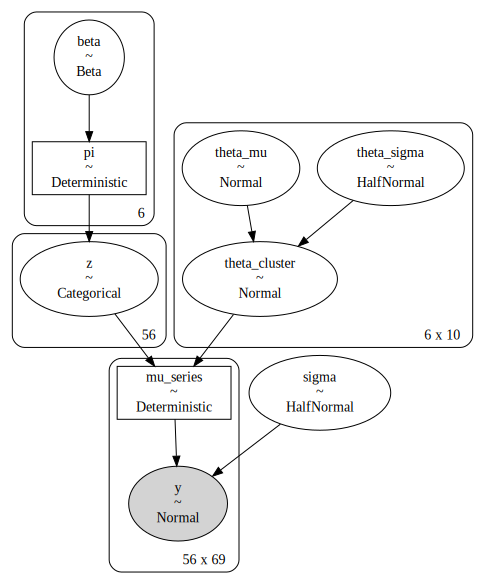

In [103]:
pm.model_to_graphviz(clusterModel)

In [104]:
for rv in clusterModel.free_RVs:
    print(rv.name, rv.eval().shape)

beta (6,)
z (56,)
theta_mu (6, 10)
theta_sigma (6, 10)
theta_cluster (6, 10)
sigma ()


In [105]:
with clusterModel:
    trace = pm.sample(
        draws=2000,
        tune=500,
        chains=4,
        target_accept=0.9
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [beta, theta_mu, theta_sigma, theta_cluster, sigma]
>CategoricalGibbsMetropolis: [z]
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 727 seconds.
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 2060 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxi

In [106]:
import arviz as az
az.summary(trace)
# az.summary(trace, var_names=["sigma_rw", "sigma_obs", "mu"])

# az.summary(trace)

/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/fran/miniconda3/envs/pyMCJax/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/fran/miniconda3/envs/pyMCJax/lib/p

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z[0],0.750,0.829,0.000,2.000,0.414,0.164,4.0,4.0,5.877474e+15
z[1],0.500,0.500,0.000,1.000,0.250,0.000,4.0,4.0,6.491245e+15
z[2],0.750,0.829,0.000,2.000,0.414,0.164,4.0,4.0,5.877474e+15
z[3],0.500,0.500,0.000,1.000,0.250,0.000,4.0,4.0,6.491245e+15
z[4],0.750,0.829,0.000,2.000,0.414,0.164,4.0,4.0,5.877474e+15
...,...,...,...,...,...,...,...,...,...
"mu_series[55, 64]",0.196,0.006,0.186,0.208,0.000,0.000,3270.0,5534.0,1.000000e+00
"mu_series[55, 65]",0.151,0.006,0.140,0.162,0.000,0.000,3064.0,3290.0,1.000000e+00
"mu_series[55, 66]",0.131,0.005,0.121,0.142,0.000,0.000,3481.0,3323.0,1.000000e+00
"mu_series[55, 67]",0.143,0.006,0.131,0.155,0.000,0.000,5049.0,3413.0,1.000000e+00


In [107]:
trace.posterior

<xarray.Dataset> Size: 263MB
Dimensions:              (chain: 4, draw: 2000, z_dim_0: 56, theta_mu_dim_0: 6,
                          theta_mu_dim_1: 10, theta_cluster_dim_0: 6,
                          theta_cluster_dim_1: 10, beta_dim_0: 6,
                          theta_sigma_dim_0: 6, theta_sigma_dim_1: 10,
                          pi_dim_0: 6, mu_series_dim_0: 56, mu_series_dim_1: 69)
Coordinates: (12/13)
  * chain                (chain) int64 32B 0 1 2 3
  * draw                 (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
  * z_dim_0              (z_dim_0) int64 448B 0 1 2 3 4 5 ... 50 51 52 53 54 55
  * theta_mu_dim_0       (theta_mu_dim_0) int64 48B 0 1 2 3 4 5
  * theta_mu_dim_1       (theta_mu_dim_1) int64 80B 0 1 2 3 4 5 6 7 8 9
  * theta_cluster_dim_0  (theta_cluster_dim_0) int64 48B 0 1 2 3 4 5
    ...                   ...
  * beta_dim_0           (beta_dim_0) int64 48B 0 1 2 3 4 5
  * theta_sigma_dim_0    (theta_sigma_dim_0) int64 48B 0 1 2 3 4 5
  * theta_sigma_dim_1    (theta_sigma_dim_1) int64 80B 0 1 2 3 4 5 6 7 8 9
  * pi_dim_0             (pi_dim_0) int64 48B 0 1 2 3 4 5
  * mu_series_dim_0      (mu_series_dim_0) int64 448B 0 1 2 3 4 ... 52 53 54 55
  * mu_series_dim_1      (mu_series_dim_1) int64 552B 0 1 2 3 4 ... 65 66 67 68
Data variables:
    z                    (chain, draw, z_dim_0) int64 4MB 0 1 0 1 0 ... 0 0 0 1
    theta_mu             (chain, draw, theta_mu_dim_0, theta_mu_dim_1) float64 4MB ...
    theta_cluster        (chain, draw, theta_cluster_dim_0, theta_cluster_dim_1) float64 4MB ...
    beta                 (chain, draw, beta_dim_0) float64 384kB 0.5138 ... 0...
    theta_sigma          (chain, draw, theta_sigma_dim_0, theta_sigma_dim_1) float64 4MB ...
    sigma                (chain, draw) float64 64kB 0.05933 0.05814 ... 0.06129
    pi                   (chain, draw, pi_dim_0) float64 384kB 0.5138 ... 0.0...
    mu_series            (chain, draw, mu_series_dim_0, mu_series_dim_1) float64 247MB ...
Attributes:
    created_at:                 2026-03-12T20:43:58.086536+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.12.0
    sampling_time:              726.7942855358124
    tuning_steps:               500

primero evaluo si mas o menos con K=8 ajusta o no 

In [108]:
# trace.posterior["theta_cluster"]
trace.posterior["mu_series"].mean(dim=["chain", "draw"]).shape

(56, 69)

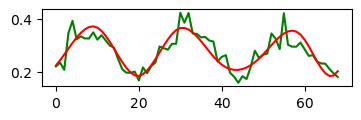

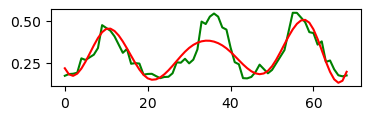

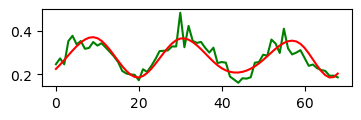

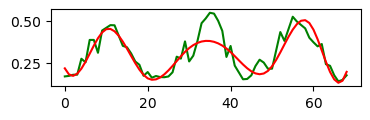

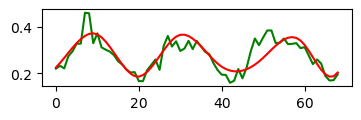

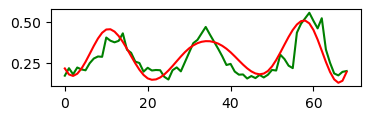

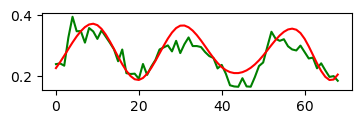

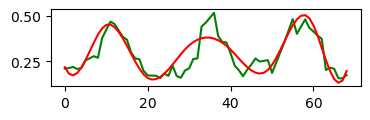

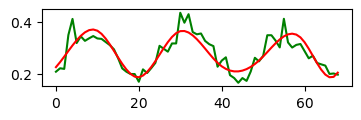

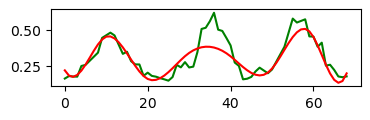

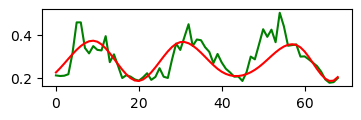

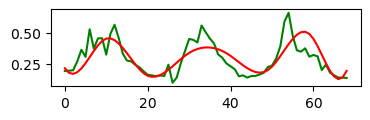

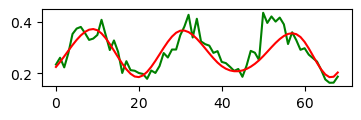

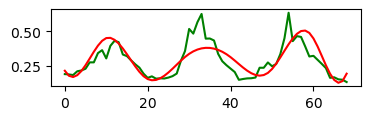

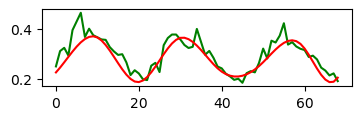

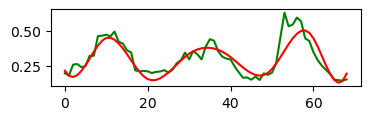

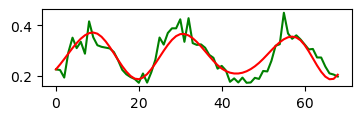

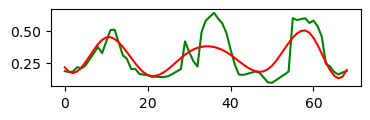

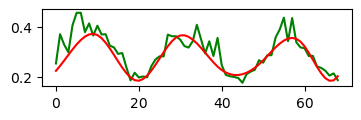

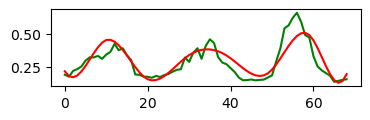

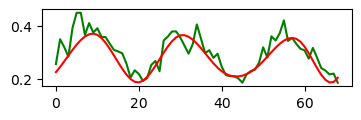

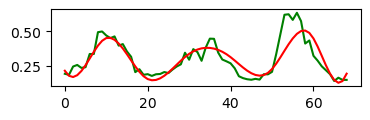

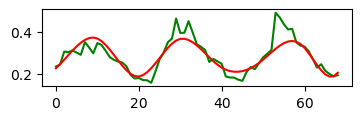

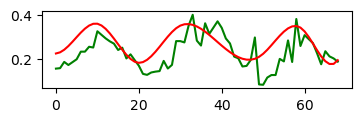

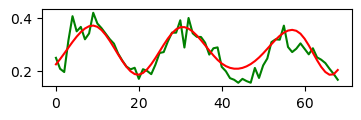

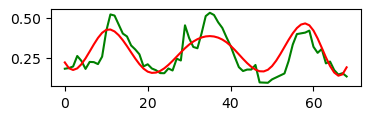

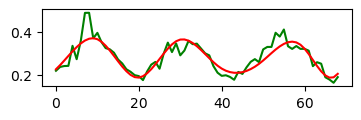

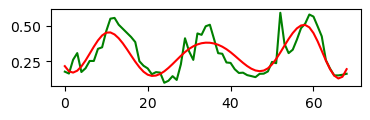

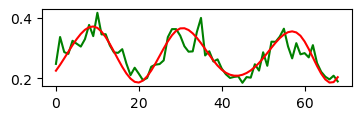

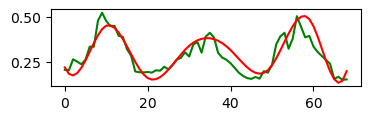

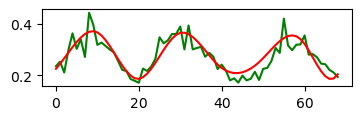

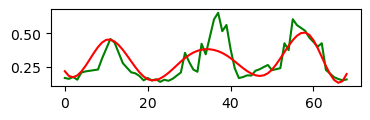

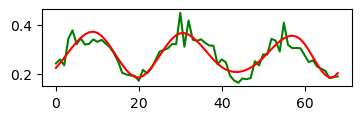

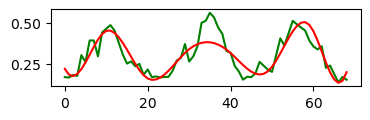

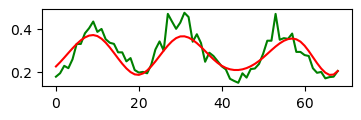

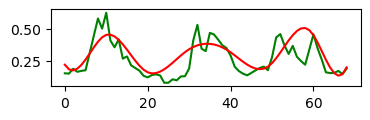

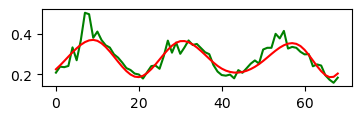

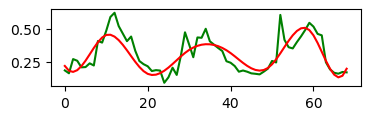

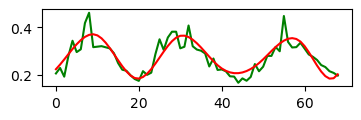

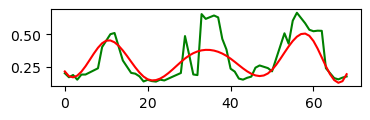

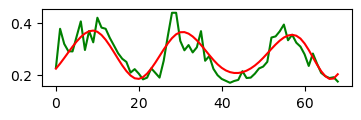

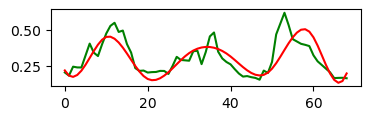

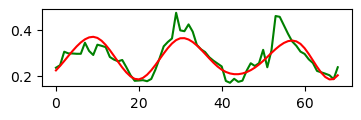

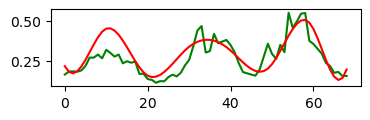

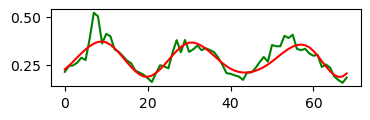

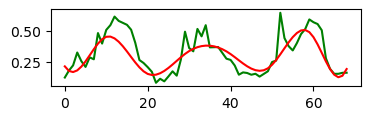

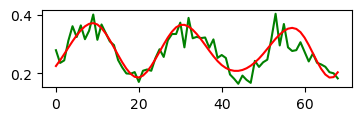

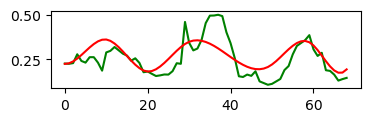

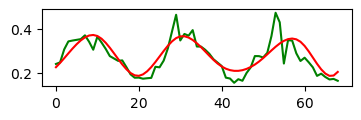

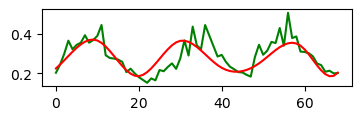

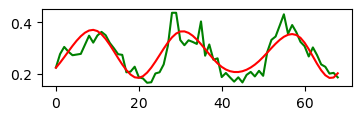

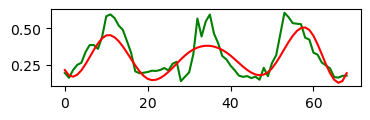

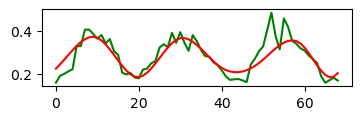

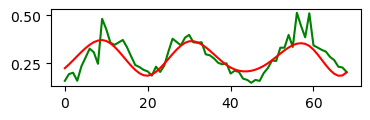

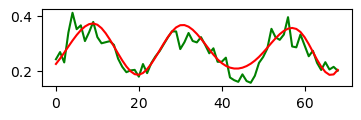

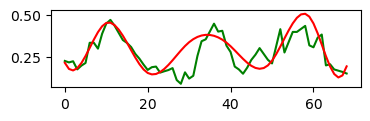

In [109]:
est_series_noBosque = trace.posterior["mu_series"].mean(dim=["chain", "draw"])
if True:   
    for b_ in range(series.shape[0]):
        plt.figure(figsize=(4,1))
        plt.plot(series[b_,:],'g')
        plt.plot(est_series_noBosque.values[b_,:],'r')
        plt.show()

In [110]:
z_mean = trace.posterior["z"].mean(dim=["chain", "draw"])

In [111]:
z_mean

<xarray.DataArray 'z' (z_dim_0: 56)> Size: 448B
array([0.75   , 0.5    , 0.75   , 0.5    , 0.75   , 0.5    , 0.75   ,
       0.5    , 0.75   , 0.5    , 0.75   , 0.5    , 0.75   , 0.5    ,
       0.75   , 0.5    , 0.75   , 0.5    , 0.75   , 0.5    , 0.75   ,
       0.5    , 0.75   , 2.     , 0.75   , 1.5    , 0.75   , 0.5    ,
       0.75   , 0.5    , 0.75   , 0.5    , 0.75   , 0.5    , 0.75   ,
       0.5    , 0.75   , 0.5    , 0.75   , 0.5    , 0.75   , 0.5    ,
       0.75   , 0.5    , 0.75   , 0.5    , 0.75   , 1.97075, 0.75   ,
       0.75   , 0.75   , 0.5    , 0.75   , 0.75   , 0.75   , 0.5    ])
Coordinates:
  * z_dim_0  (z_dim_0) int64 448B 0 1 2 3 4 5 6 7 8 ... 48 49 50 51 52 53 54 55

Ahora grafico los valores medios y anchos de los clusters

In [112]:
clusters_mean = trace.posterior["theta_cluster"].mean(dim=["chain", "draw"])

In [113]:
clusters_mean.shape

(6, 10)

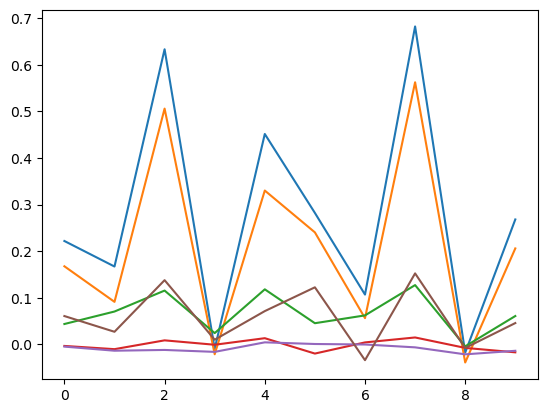

In [114]:
plt.plot(clusters_mean.values.T)

Comparo firmas de los valores medios de los clusters con firmas reales 

In [115]:
cluster_curve = B @ clusters_mean[0,:].values

Text(0, 0.5, 'NDVI')

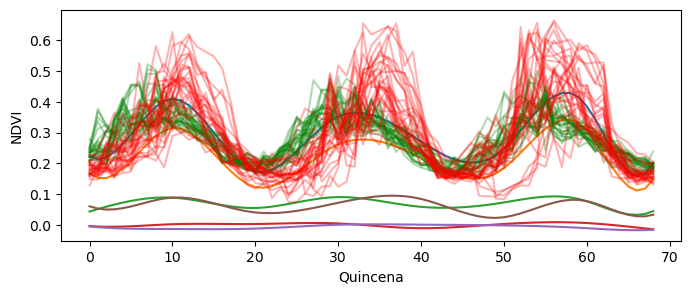

In [116]:
fig = plt.figure(figsize=(8,3))

for i in range(clusters_mean.shape[0]):
    cluster_curve = B @ clusters_mean[i,:].values
    plt.plot(cluster_curve)

plt.plot(quincenas, bosques.T, color='green', alpha=0.3)
plt.plot(quincenas, no_bosques.T, color='red', alpha=0.3)
plt.xlabel("Quincena")
plt.ylabel("NDVI")
# plt.title("Series reales con clusters conocidos")

Observaciones:

1. Falta power para que agarre los rojos. De la figura del random que explora el spam, se ve que no llega tan arriba. Hay que modificar eso.

2. Quizas clasificar solo con noBosque? asi sacamos lo que mete ruido?

In [ ]:
z_post = trace.posterior["z"].mean(dim=("chain","draw")).values
z_est = np.round(z_post).astype(int)

In [ ]:
print("True clusters:")
print(true_clusters)
print("Estimated clusters:")
print(z_est)
print("Estimated N:", len(np.unique(z_est)))

### Evaluacion clusters

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def aligned_confusion(true_labels, est_labels):
    true_labels = np.array(true_labels)
    est_labels  = np.array(est_labels)

    cm = confusion_matrix(true_labels, est_labels)

    # Hungarian algorithm → maximizar diagonal
    row_ind, col_ind = linear_sum_assignment(-cm)

    aligned_cm = cm[:, col_ind]
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}

    aligned_est = np.array([mapping[e] for e in est_labels])

    return aligned_cm, aligned_est, mapping


In [ ]:
def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Estimated cluster")
    plt.ylabel("True cluster")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j],
                     ha="center", va="center",
                     fontsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
uniques = np.unique(z_est)

In [ ]:
# z_est[z_est == 4] = 3

In [ ]:
cm, aligned_est, mapping = aligned_confusion(true_clusters, z_est)

print("Cluster mapping:", mapping)
plot_confusion(cm)


Evaluacion series de tiempo

In [ ]:
def extract_cluster_signatures(trace, z_est):

    x_post = trace.posterior["x"]

    # media posterior
    x_mean = x_post.mean(dim=("chain","draw")).values

    # desviación estándar posterior
    x_std = x_post.std(dim=("chain","draw")).values

    # tamaño de clusters
    clusters = np.unique(z_est)
    cluster_size = {k: np.sum(z_est == k) for k in clusters}

    signatures = {}

    for k in clusters:

        signatures[k] = {
            "mean": x_mean[k],
            "std": x_std[k],
            "size": cluster_size[k]
        }

    return signatures

In [ ]:
# import matplotlib.pyplot as plt

def plot_cluster_signatures(signatures):

    for k, s in signatures.items():

        mu = s["mean"]
        sd = s["std"]
        n  = s["size"]

        t = np.arange(len(mu))

        plt.plot(t, mu, label=f"cluster {k} (n={n})")

        plt.fill_between(
            t,
            mu - 1*sd,
            mu + 1*sd,
            alpha=0.2
        )

    plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.2)
    plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.2)

    plt.ylim(0.1, 0.6)
    plt.xlabel("time")
    plt.ylabel("NDVI")
    plt.legend()
    plt.show()

In [ ]:
signatures = extract_cluster_signatures(trace, z_est)

plot_cluster_signatures(signatures)

In [ ]:
def plot_cluster_ndvi_posterior(trace, z_est, ci=0.9):
    """
    trace   : trace de PyMC
    z_est   : cluster asignado por serie
    """

    a_post = trace.posterior["a"].stack(sample=("chain","draw")).values
    # shape = (Kmax, N_segments, n_samples)

    clusters = np.unique(z_est)
    # bins = np.floor((days % 365) / 365 * n_segments).astype(int)

    plt.figure(figsize=(10,4))
    
    for k in clusters:

        samples = a_post[k, quincenas[:23], :]  # (365, n_samples)

        mean = samples.mean(axis=1)
        low  = np.percentile(samples, (1-ci)/2*100, axis=1)
        high = np.percentile(samples, (1+(ci))/2*100, axis=1)

        n_series = np.sum(z_est == k)

        plt.plot(quincenas[:23], mean, label=f"Cluster {k} (n={n_series})")
        plt.fill_between(quincenas[:23], low, high, alpha=0.25)

    # series reales
    # plt.plot(quincenas[:23], series[true_clusters, :23].mean(axis=0), color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas[:23], series[true_clusters == 1, :].T[:23], color='red', alpha=0.1)
    # plt.plot(quincenas[:23], series[true_clusters == 2, :].T[:23], color='blue', alpha=0.1)

    #Este anda!
    # plt.plot(quincenas, series[0::2, :23].mean(axis=0), linestyle=':', color='green', alpha=0.5, label="Bosque medio")
    # plt.plot(quincenas, series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")

    plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.1) #, label="Bosque medio"
    plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.1) #, label="No Bosque medio"

    plt.xlim(0, 23)
    plt.ylim(0.1, 0.6)

    plt.xlabel("Quincena")
    plt.ylabel("NDVI")
    plt.title("NDVI promedio por cluster (posterior PyMC)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
plot_cluster_ndvi_posterior(trace, z_est, ci=0.9)

In [ ]:
series[true_clusters, :23].mean(axis=0)

In [ ]:
series[1::2, :23].shape

In [ ]:
plt.plot(quincenas[:23], series[1::2, :23].mean(axis=0), linestyle=':', color='red', alpha=0.5, label="No Bosque medio")


In [ ]:
quincenas.shape

In [ ]:
plt.plot(quincenas, series[0::2, :].T, linestyle=':', color='green', alpha=0.5, label="Bosque medio")
plt.plot(quincenas, series[1::2, :].T, linestyle=':', color='red', alpha=0.5, label="No Bosque medio")